In [1]:
import joblib
import pandas as pd

exercise = pd.read_csv("exercise (1).csv")
calories = pd.read_csv("calories.csv")

df = exercise.merge(calories,on = "User_ID")
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190,94,29,105,40.8,231
1,14861698,female,20,166,60,14,94,40.3,66
2,11179863,male,69,179,79,5,88,38.7,26
3,16180408,female,34,179,71,13,100,40.5,71
4,17771927,female,27,154,58,10,81,39.8,35


In [2]:
df.shape

(15000, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  int64  
 4   Weight      15000 non-null  int64  
 5   Duration    15000 non-null  int64  
 6   Heart_Rate  15000 non-null  int64  
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 1.0+ MB


In [4]:
df = df.drop("User_ID",axis = 1)
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190,94,29,105,40.8,231
1,female,20,166,60,14,94,40.3,66
2,male,69,179,79,5,88,38.7,26
3,female,34,179,71,13,100,40.5,71
4,female,27,154,58,10,81,39.8,35


In [5]:
df.shape

(15000, 8)

In [6]:
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190,94,29,105,40.8,231
1,female,20,166,60,14,94,40.3,66
2,male,69,179,79,5,88,38.7,26
3,female,34,179,71,13,100,40.5,71
4,female,27,154,58,10,81,39.8,35


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  object 
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  int64  
 3   Weight      15000 non-null  int64  
 4   Duration    15000 non-null  int64  
 5   Heart_Rate  15000 non-null  int64  
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 937.6+ KB


In [8]:
df.isnull().sum()

Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [9]:
df.describe()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

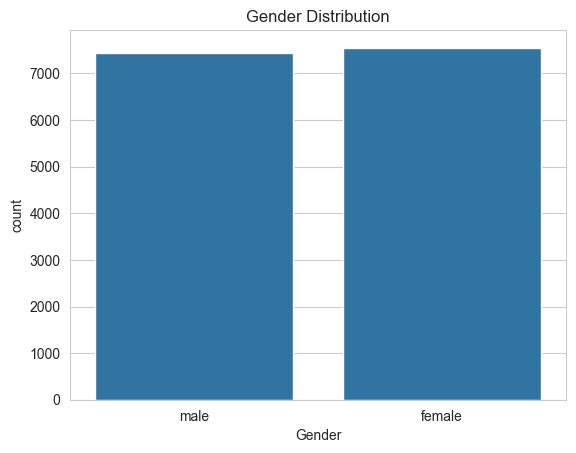

In [11]:
sns.countplot(x = "Gender",data = df)
plt.title("Gender Distribution")
plt.show()

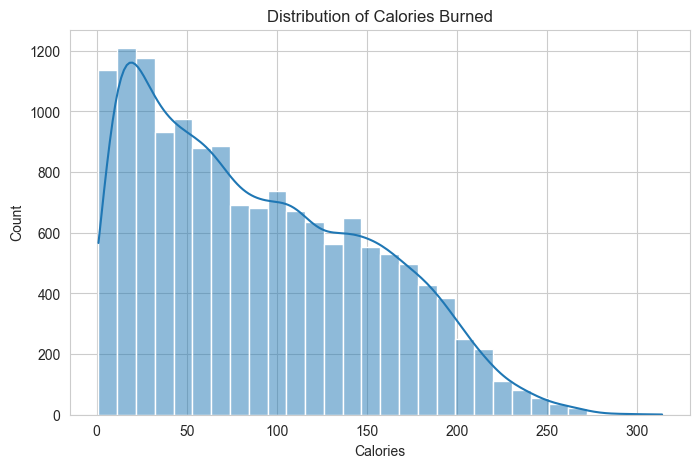

In [12]:
plt.figure(figsize = (8,5))
sns.histplot(df["Calories"],bins = 30 , kde = True)
plt.title("Distribution of Calories Burned")
plt.show()

In [13]:
df["Gender"] = df["Gender"].map({"male":1,"female":0})

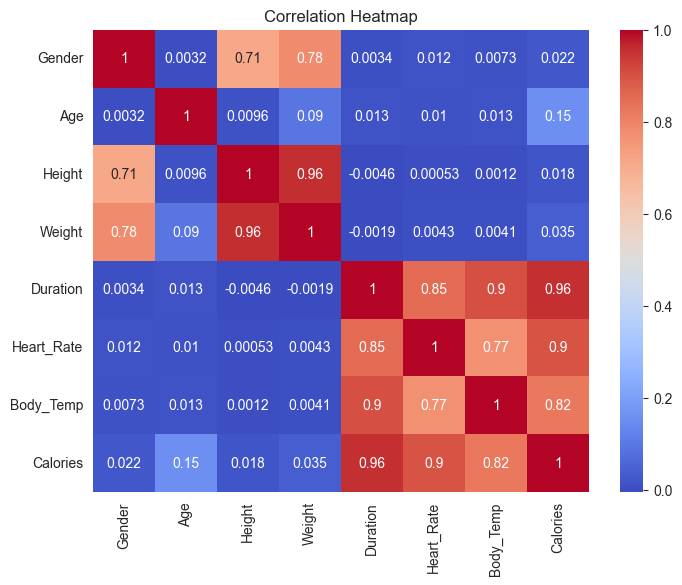

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot = True , cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
X = df.drop("Calories",axis = 1)
y = df['Calories']

print(X.head())
print(y.head())

   Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0       1   68     190      94        29         105       40.8
1       0   20     166      60        14          94       40.3
2       1   69     179      79         5          88       38.7
3       0   34     179      71        13         100       40.5
4       0   27     154      58        10          81       39.8
0    231
1     66
2     26
3     71
4     35
Name: Calories, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ -1.37, 0.5 , -0.17,..., 6.63, 1.99,-16.94]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Gender','Age','Height',...,'Duration','Heart_Rate','Body_Temp']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,461.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7


In [18]:
y_pred = model.predict(X_test)
print(y_pred[:5])

[170.67646027 192.08857813  56.14796403 155.47641482 212.45066668]


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test,y_pred)

In [20]:
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 score:",r2)

MAE: 8.44151355384971
MSE: 131.99574575081704
RMSE: 11.488940149152882
R2 score: 0.9672937151257295


In [21]:
comparison = pd.DataFrame({"Actual":y_test.values,"Predicted": y_pred})
comparison.head(10)

,Actual,Predicted
0,173,170.676460
1,189,192.088578
2,53,56.147964
3,161,155.476415
4,226,212.450667
5,179,184.531237
6,98,94.301887
7,44,49.978594
8,79,82.067060
9,59,56.582915


In [22]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state = 42)
dt_model.fit(X_train,y_train)
dt_pred = dt_model.predict(X_test)
dt_mae = mean_absolute_error(y_test,dt_pred)
dt_rmse = mean_squared_error(y_test,dt_pred)**0.5
dt_r2 = r2_score(y_test,dt_pred)
                        

In [23]:
print("Decision Tree MAE :",dt_mae)
print("Decision Tree RMSE :" , dt_rmse)
print("Decision Tree R2 :" , dt_r2)

Decision Tree MAE : 3.437333333333333
Decision Tree RMSE : 5.335853571204267
Decision Tree R2 : 0.9929452912784914


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)

In [25]:
print("\n Random Forest Results")
print("MAE:",mean_absolute_error(y_test,rf_pred))
print("RMSE :", mean_squared_error(y_test,rf_pred)**0.5)
print("R2 Score:" , r2_score(y_test,rf_pred))


 Random Forest Results
MAE: 1.7173133333333332
RMSE : 2.6833820078401063
R2 Score: 0.9982158297720679


In [26]:
results = pd.DataFrame({"Model": ["Linear Regression","Decision Tree", "Random Forest"],
                        "MAE":[mean_absolute_error(y_test,y_pred),mean_absolute_error(y_test,dt_pred),mean_absolute_error(y_test,rf_pred)],
                        "RMSE": [mean_squared_error(y_test,y_pred)**0.5, mean_squared_error(y_test,dt_pred)**0.5,mean_squared_error(y_test,rf_pred)**0.5],
                        "R2 Score": [r2_score(y_test,y_pred), r2_score(y_test,dt_pred), r2_score(y_test,rf_pred)]})
print(results)

               Model       MAE       RMSE  R2 Score
0  Linear Regression  8.441514  11.488940  0.967294
1      Decision Tree  3.437333   5.335854  0.992945
2      Random Forest  1.717313   2.683382  0.998216


In [27]:
import joblib 
joblib.dump(rf_model,"calorie_burn_prediction_model.pkl")
print("Model saved successfully! ")

Model saved successfully! 


In [28]:
loaded_model = joblib.load("calorie_burn_prediction_model.pkl")
sample = [[1,24,175,70,30,95,40]]

prediction = loaded_model.predict(sample)
print("Predicted Calories Burned:" , prediction[0])

Predicted Calories Burned: 135.15


C:\Users\Uday Bhaskar Dutta\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
